# Phase 4 — Evaluation & Analysis

**Objective.** Quantitatively and qualitatively evaluate the trained CRNN-CTC
model on the held-out test split of the RealBook-PrIMuS dataset. We measure
the **Symbol Error Rate (SER)** — edit distance at the LMX token level —
then drill into per-sample statistics, representative predictions, and
failure modes.

| Section | Purpose |
|---|---|
| 1. Setup & Initialisation | Load config, vocab, model checkpoint |
| 2. Test Dataset Loading | Instantiate the held-out test split |
| 3. Training Curves | Plot loss & SER from the training log |
| 4. Quantitative Evaluation | Aggregate SER over the full test set |
| 5. Qualitative Analysis | Visual side-by-side of predictions |
| 6. Error Analysis | Worst-case failures & error-type breakdown |

---
## 1. Setup & Initialisation

Import all required libraries, apply the project-wide style, load the
configuration dataclass, vocabulary mapping, and the best saved model
checkpoint. The model is set to evaluation mode and moved to the
appropriate device (GPU if available).

In [17]:
# ── Project-wide style ──────────────────────────────────────────────────
import sys
sys.path.insert(0, "../src")  # CRNN_CTC.* imports
sys.path.insert(0, "..")      # src.* pickle paths (checkpoint compatibility)
import style; style.apply()

# ── Standard / third-party ──────────────────────────────────────────────
import collections
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.amp import autocast
from torch.utils.data import DataLoader

# ── Project modules ─────────────────────────────────────────────────────
from CRNN_CTC.config import Config
from CRNN_CTC.vocab import Vocabulary
from CRNN_CTC.model import CRNN
from CRNN_CTC.dataset import make_splits, collate_fn
from CRNN_CTC.evaluate import greedy_decode, _edit_distance, symbol_error_rate

# ── Paths (relative to notebook dir, resolved via Config) ───────────────
NOTEBOOK_DIR = Path.cwd()
cfg = Config()

# Make paths absolute (Config stores repo-relative paths)
DATA_DIR   = (NOTEBOOK_DIR / ".." / cfg.data_dir).resolve()
VOCAB_PATH = (NOTEBOOK_DIR / ".." / cfg.vocab_path).resolve()
CHECKPOINT = (NOTEBOOK_DIR / ".." / cfg.model_dir / "best_model.pt").resolve()
LOG_PATH   = (NOTEBOOK_DIR / ".." / cfg.model_dir / "training_log.csv").resolve()

print(f"Data dir   : {DATA_DIR}")
print(f"Vocab path : {VOCAB_PATH}")
print(f"Checkpoint : {CHECKPOINT}")
print(f"Log path   : {LOG_PATH}")

Data dir   : /var/home/pol-linux/Uni/TFG-OMR/data/realbook_primus_aa
Vocab path : /var/home/pol-linux/Uni/TFG-OMR/src/CRNN_CTC/vocabulary.txt
Checkpoint : /var/home/pol-linux/Uni/TFG-OMR/models/best_model.pt
Log path   : /var/home/pol-linux/Uni/TFG-OMR/models/training_log.csv


In [18]:
# ── Device ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print(f"Device: {device}  |  AMP: {use_amp}")

# ── Vocabulary ──────────────────────────────────────────────────────────
vocab = Vocabulary.from_file(VOCAB_PATH)
print(f"Vocabulary size: {len(vocab)} tokens (incl. blank + pad)")

# ── Module alias fix ────────────────────────────────────────────────────
# The checkpoint was serialised with PyTorch pickle using 'src.CRNN_CTC.*'
# module paths (training ran from the repo root with src/ on sys.path as a
# namespace). The notebook only adds '../src', so 'CRNN_CTC' is importable
# but 'src.CRNN_CTC' is not. We inject aliases so pickle can find them.
import importlib, types as _types
_src = sys.modules.setdefault("src", _types.ModuleType("src"))
import CRNN_CTC as _pkg
sys.modules.setdefault("src.CRNN_CTC", _pkg)
for _sub in ("config", "vocab", "model", "dataset", "train", "evaluate"):
    _mod = importlib.import_module(f"CRNN_CTC.{_sub}")
    sys.modules.setdefault(f"src.CRNN_CTC.{_sub}", _mod)

# ── Model ───────────────────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model = CRNN(
    vocab_size=ckpt.get("vocab_size", len(vocab)),
    cnn_out_channels=cfg.cnn_out_channels,
    rnn_hidden=cfg.rnn_hidden,
    rnn_layers=cfg.rnn_layers,
    dropout=0.0,  # no dropout at inference
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
best_epoch = ckpt.get("epoch", -1)
best_ser   = ckpt.get("val_ser", -1)
print(f"Parameters : {n_params:,}")
print(f"Best epoch : {best_epoch}  |  Val SER @ save: {best_ser:.4f}")


Device: cuda  |  AMP: True
Vocabulary size: 94 tokens (incl. blank + pad)
Parameters : 4,229,598
Best epoch : 18  |  Val SER @ save: 0.2305


---
## 2. Test Dataset Loading

We use the same deterministic split (`seed=42`) as training to guarantee
the test set is the exact held-out partition the model has **never** seen.
The dataloader fetches batches without shuffling so results are reproducible.

In [19]:
_, _, test_ds = make_splits(
    data_dir=DATA_DIR,
    vocab=vocab,
    img_height=cfg.img_height,
    scanned_dir=None,
    val_frac=cfg.val_frac,
    test_frac=cfg.test_frac,
    seed=cfg.seed,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=collate_fn,
    pin_memory=True,
)

print(f"Test samples : {len(test_ds)}")
print(f"Test batches : {len(test_loader)}")

Test samples : 4355
Test batches : 273


---
## 3. Training Curves

Plot loss and SER evolution over the training run to verify convergence
and detect over-fitting. The dashed vertical line marks the epoch whose
checkpoint we loaded.

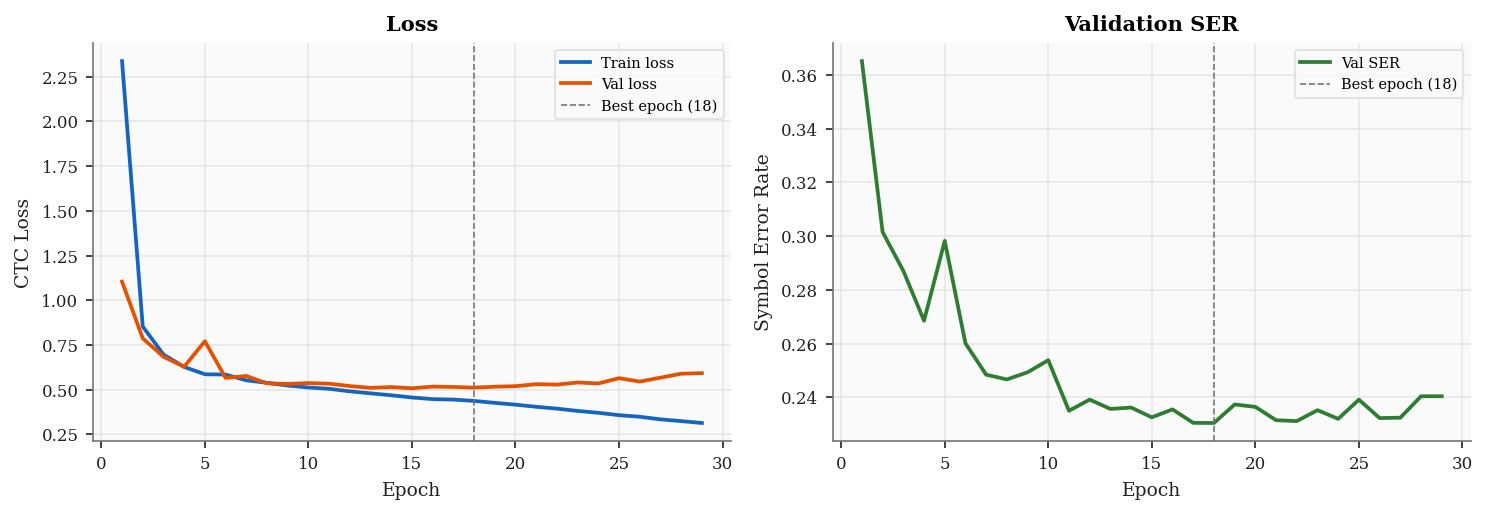

Final training loss : 0.3133
Best  val SER       : 0.2305 (epoch 18)


In [20]:
import csv

# Parse the training log
epochs, train_loss, val_loss, val_ser = [], [], [], []
with open(LOG_PATH) as f:
    reader = csv.DictReader(f)
    for r in reader:
        epochs.append(int(r["epoch"]))
        train_loss.append(float(r["train_loss"]))
        val_loss.append(float(r["val_loss"]))
        val_ser.append(float(r["val_ser"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# ── Loss curves ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, train_loss, label="Train loss", color=style.C["primary"])
ax.plot(epochs, val_loss,   label="Val loss",   color=style.C["secondary"])
ax.axvline(best_epoch, ls="--", lw=0.8, color=style.C["neutral_mid"],
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("CTC Loss")
ax.set_title("Loss")
ax.legend(fontsize=7)

# ── SER curve ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, val_ser, color=style.C["tertiary"], label="Val SER")
ax.axvline(best_epoch, ls="--", lw=0.8, color=style.C["neutral_mid"],
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Symbol Error Rate")
ax.set_title("Validation SER")
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

print(f"Final training loss : {train_loss[-1]:.4f}")
print(f"Best  val SER       : {min(val_ser):.4f} (epoch {epochs[int(np.argmin(val_ser))]})")

---
## 4. Quantitative Evaluation — Global Metrics

Run inference over the **entire** test set in `torch.inference_mode()`.
For every sample we store the predicted sequence, the ground-truth sequence,
the edit distance, and the per-sample SER.

$$
\text{SER} = \frac{\sum_i \operatorname{edit\_dist}(\hat{y}_i, y_i)}
              {\sum_i |y_i|}
$$

In [21]:
results: list[dict] = []  # per-sample records
total_edits = 0
total_syms  = 0

with torch.inference_mode():
    for batch in test_loader:
        images      = batch["images"].to(device)
        labels      = batch["labels"].to(device)
        label_lens  = batch["label_lens"].to(device)
        image_widths = batch["image_widths"].to(device)
        sids        = batch["sample_ids"]

        with autocast("cuda", enabled=use_amp):
            log_probs, output_lens = model(images, image_widths)

        preds = greedy_decode(log_probs, output_lens, vocab)

        # Unpack flat CTC targets into per-sample ground-truth lists
        offset = 0
        for i, length in enumerate(label_lens):
            l = length.item()
            ref = vocab.decode(labels[offset : offset + l].tolist())
            offset += l

            ed  = _edit_distance(preds[i], ref)
            ser = ed / max(len(ref), 1)

            total_edits += ed
            total_syms  += len(ref)

            results.append({
                "sid":  sids[i],
                "pred": preds[i],
                "ref":  ref,
                "ed":   ed,
                "ser":  ser,
            })

agg_ser = total_edits / max(total_syms, 1)
sers    = np.array([r["ser"] for r in results])

print(f"{'Test samples':.<30s} {len(results):>8d}")
print(f"{'Total edits':.<30s} {total_edits:>8d}")
print(f"{'Total reference symbols':.<30s} {total_syms:>8d}")
print(f"{'Aggregate SER':.<30s} {agg_ser:>8.4f}")
print(f"{'Median per-sample SER':.<30s} {np.median(sers):>8.4f}")
print(f"{'Perfect predictions (SER=0)':.<30s} {(sers == 0).sum():>8d}  "
      f"({(sers == 0).mean() * 100:.1f}%)")
print(f"{'SER ≤ 0.05':.<30s} {(sers <= 0.05).sum():>8d}  "
      f"({(sers <= 0.05).mean() * 100:.1f}%)")
print(f"{'SER ≤ 0.10':.<30s} {(sers <= 0.10).sum():>8d}  "
      f"({(sers <= 0.10).mean() * 100:.1f}%)")
print(f"{'SER > 1.0':.<30s} {(sers > 1.0).sum():>8d}  "
      f"({(sers > 1.0).mean() * 100:.1f}%)")

Test samples..................     4355
Total edits...................    64886
Total reference symbols.......   240519
Aggregate SER.................   0.2698
Median per-sample SER.........   0.1600
Perfect predictions (SER=0)...     1142  (26.2%)
SER ≤ 0.05....................     1607  (36.9%)
SER ≤ 0.10....................     1908  (43.8%)
SER > 1.0.....................       56  (1.3%)


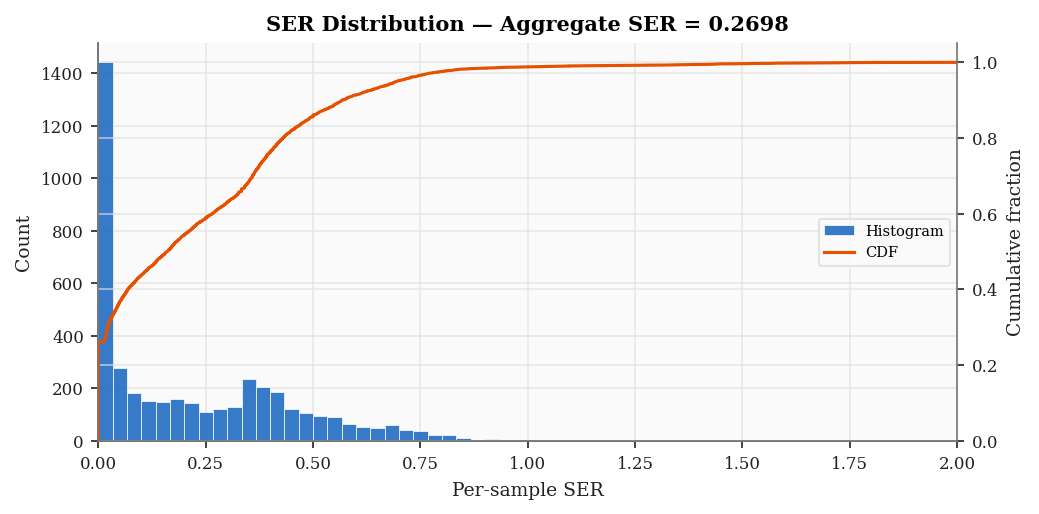

In [22]:
# ── SER distribution histogram + CDF overlay ──────────────────────────
clipped = np.clip(sers, 0, 2.0)  # clip outliers for readability

fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(0, 2.0, 61)
ax.hist(clipped, bins=bins, color=style.C["primary"], edgecolor="white",
        linewidth=0.4, alpha=0.85, label="Histogram")

# CDF on a twin axis
ax2 = ax.twinx()
sorted_ser = np.sort(sers)
cdf = np.arange(1, len(sorted_ser) + 1) / len(sorted_ser)
ax2.plot(sorted_ser, cdf, color=style.C["secondary"], lw=1.5, label="CDF")
ax2.set_ylabel("Cumulative fraction")
ax2.set_ylim(0, 1.05)
ax2.spines["right"].set_visible(True)

ax.set_xlabel("Per-sample SER")
ax.set_ylabel("Count")
ax.set_title(f"SER Distribution — Aggregate SER = {agg_ser:.4f}")
ax.set_xlim(0, 2.0)

# Combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center right", fontsize=7)

fig.tight_layout()
plt.show()

---
## 5. Qualitative Analysis — Visual Inspection

Randomly sample a handful of test images and display them alongside
their **ground-truth** and **predicted** LMX token sequences. For each
sample the edit distance is printed so we can immediately gauge prediction
quality.

In [23]:
import textwrap

def show_predictions(
    results: list[dict],
    test_ds,
    *,
    indices: np.ndarray | None = None,
    n: int = 6,
    seed: int = 0,
    title_prefix: str = "",
) -> None:
    """Plot *n* test images, each immediately followed by GT / PRED text.

    Each sample is emitted as its own figure + print block so the text
    output sits directly below its image in the notebook.
    """
    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(len(results), size=min(n, len(results)), replace=False)
        indices = np.sort(indices)

    if title_prefix:
        print(f"{'─' * 70}")
        print(f"  {title_prefix}")
        print(f"{'─' * 70}\n")

    WRAP = 110  # characters per line for token sequences

    for i, idx in enumerate(indices):
        r = results[idx]
        sample = test_ds[idx]
        img = sample["image"].squeeze(0).numpy()

        # ── One figure per sample ────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(13, 2.2))
        ax.imshow(img, cmap="gray", aspect="auto")
        ax.set_xticks([])
        ax.set_yticks([])

        ser_colour = (style.C["tertiary"]  if r["ser"] < 0.05
                      else style.C["secondary"] if r["ser"] < 0.30
                      else style.C["highlight"])
        ax.set_title(
            f"[{i+1}/{len(indices)}]  {r['sid']}   "
            f"ED = {r['ed']}   SER = {r['ser']:.3f}",
            fontsize=9, color=ser_colour, loc="left", pad=4,
        )
        fig.tight_layout()
        plt.show()

        # ── GT / PRED as plain printed text ──────────────────────────────
        ref_str  = " ".join(r["ref"])  if r["ref"]  else "(empty)"
        pred_str = " ".join(r["pred"]) if r["pred"] else "(empty)"

        indent = "         "  # align continuation lines with the token start
        gt_lines   = textwrap.fill(ref_str,  width=WRAP,
                                   initial_indent="GT:    ",
                                   subsequent_indent=indent)
        pred_lines = textwrap.fill(pred_str, width=WRAP,
                                   initial_indent="PRED:  ",
                                   subsequent_indent=indent)

        print(gt_lines)
        print(pred_lines)
        print()


──────────────────────────────────────────────────────────────────────
  Random sample — qualitative check
──────────────────────────────────────────────────────────────────────



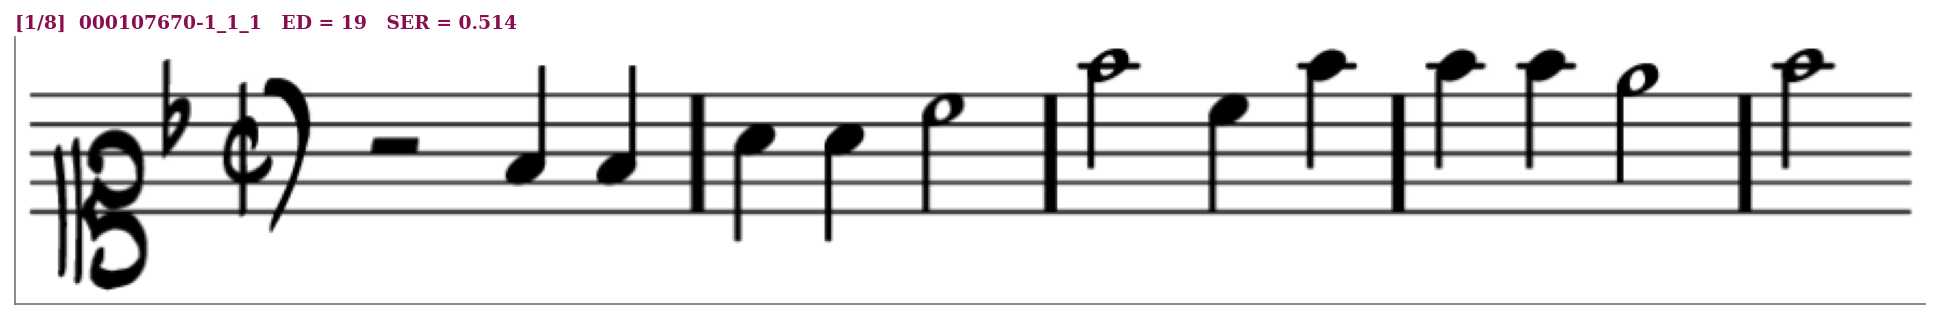

GT:    measure key:fifths:-1 time beats:2 beat-type:2 clef:C1 rest half F4 quarter F4 quarter measure A4
         quarter A4 quarter C5 half measure F5 half C5 quarter F5 quarter F5 quarter F5 quarter E5 half
         measure F5 half rest half
PRED:  measure key:fifths:-1 time beats:2 beat-type:2 clef:C4 rest rest:measure measure rest half G3 quarter
         G3 quarter measure B3 quarter B3 quarter D4 half G4 half D4 quarter G4 quarter measure G4 quarter G4
         quarter F4 half G4 half rest half



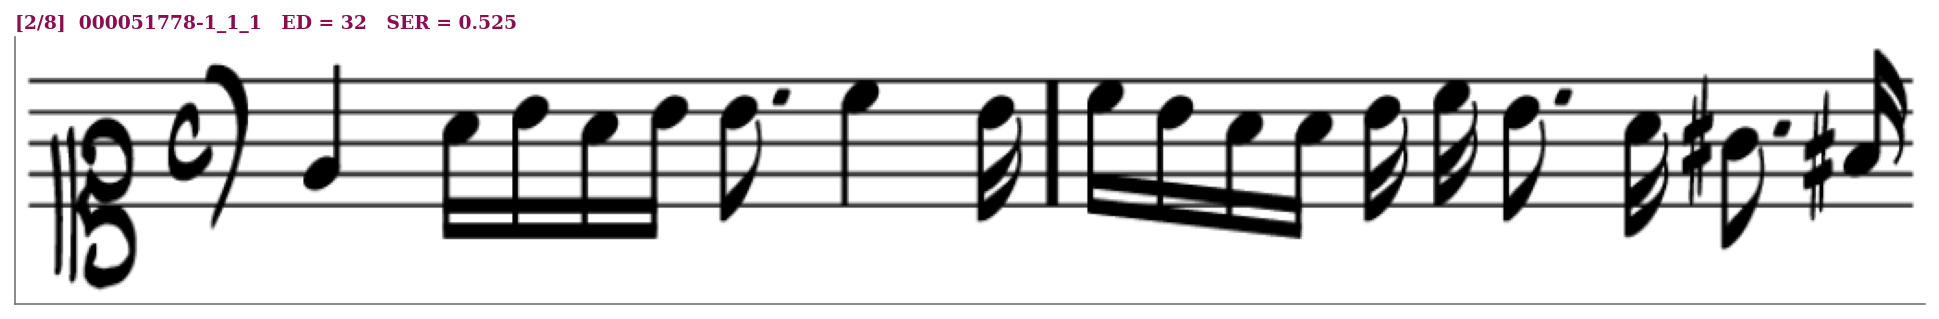

GT:    measure time beats:4 beat-type:4 clef:C1 E4 quarter rest half dot measure A4 16th B4 16th A4 16th B4
         16th B4 eighth dot A4 32nd B4 32nd C5 quarter B4 16th C5 32nd D5 32nd C5 16th B4 16th measure A4 16th
         A4 16th B4 16th C5 16th B4 eighth dot A4 16th G4 eighth dot sharp F4 16th sharp rest quarter
PRED:  measure time beats:4 beat-type:4 clef:C4 F3 quarter B3 16th C4 16th B3 16th C4 16th C4 eighth dot D4
         32nd C4 32nd D4 quarter C4 16th D4 16th C4 16th B3 16th B3 16th C4 16th D4 16th C4 eighth dot B3 16th
         A3 eighth dot sharp G3 16th sharp



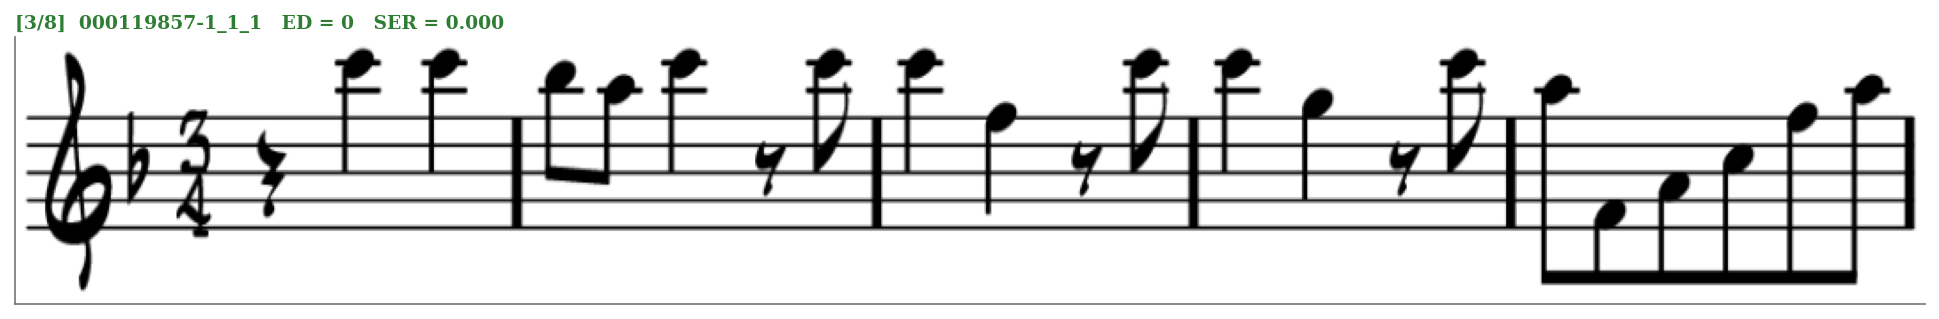

GT:    measure key:fifths:-1 time beats:3 beat-type:4 clef:G2 rest quarter C6 quarter C6 quarter measure B5
         eighth A5 eighth C6 quarter rest eighth C6 eighth measure C6 quarter F5 quarter rest eighth C6 eighth
         measure C6 quarter G5 quarter rest eighth C6 eighth measure A5 eighth F4 eighth A4 eighth C5 eighth
         F5 eighth A5 eighth
PRED:  measure key:fifths:-1 time beats:3 beat-type:4 clef:G2 rest quarter C6 quarter C6 quarter measure B5
         eighth A5 eighth C6 quarter rest eighth C6 eighth measure C6 quarter F5 quarter rest eighth C6 eighth
         measure C6 quarter G5 quarter rest eighth C6 eighth measure A5 eighth F4 eighth A4 eighth C5 eighth
         F5 eighth A5 eighth



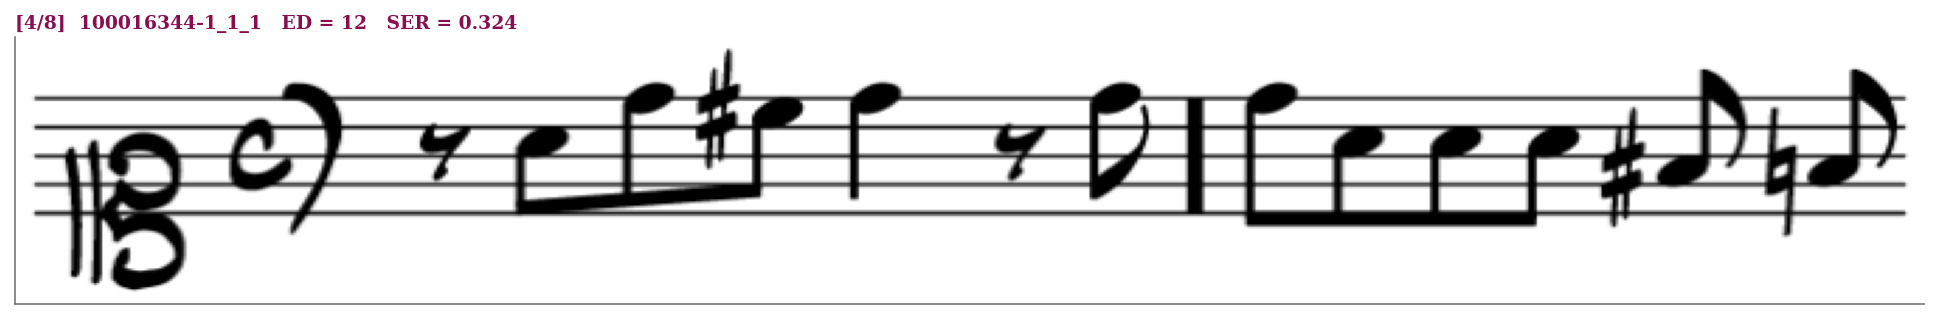

GT:    measure time beats:4 beat-type:4 clef:C1 rest eighth A4 eighth D5 eighth C5 eighth sharp D5 quarter
         rest eighth D5 eighth measure D5 eighth A4 eighth A4 eighth A4 eighth F4 eighth sharp F4 eighth
         natural rest quarter
PRED:  measure time beats:4 beat-type:4 clef:C4 rest eighth B3 eighth E4 eighth D4 eighth sharp E4 quarter
         rest eighth E4 eighth measure E4 eighth B3 eighth B3 eighth B3 eighth G3 eighth sharp G3 eighth
         natural rest quarter



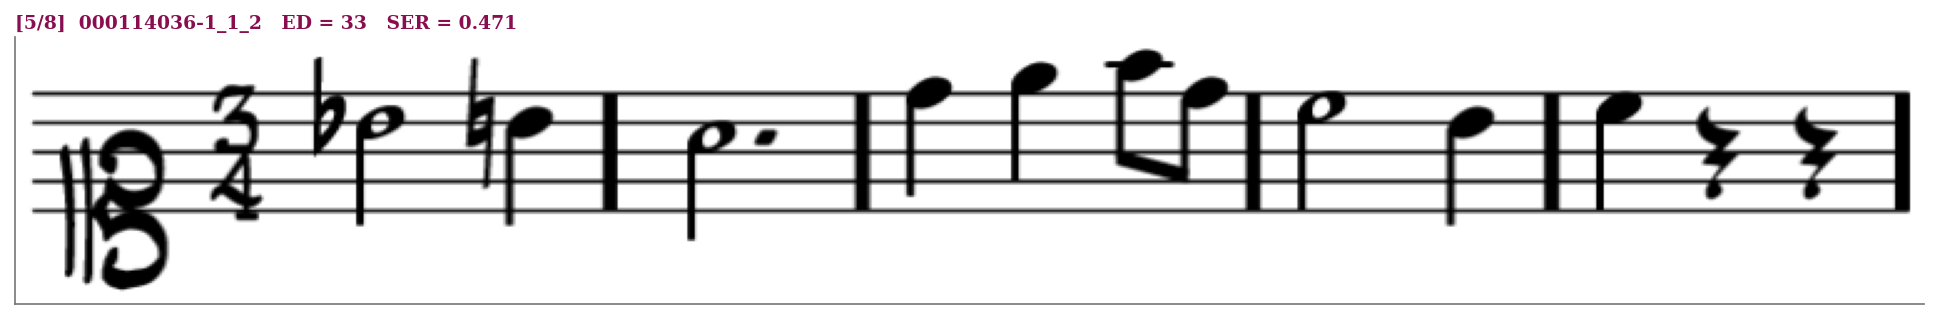

GT:    measure time beats:3 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure rest quarter
         measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure B4 half flat B4 quarter natural measure A4 half dot measure D5
         quarter E5 quarter F5 eighth D5 eighth measure C5 half B4 quarter measure C5 quarter rest quarter
         rest quarter measure rest rest:measure measure rest rest:measure rest quarter measure rest quarter
PRED:  measure time beats:3 beat-type:4 clef:C4 rest rest:measure measure rest rest measure rest rest quarter
         measure rest rest rest:measure half flat measure rest:measure C4 quarter natural measure B3 half dot
         measure E4 quarter F4 quarter G4 eighth G4 eighth measure D4 half C4 quarter measure D4 quarter rest
         quarter rest quarter



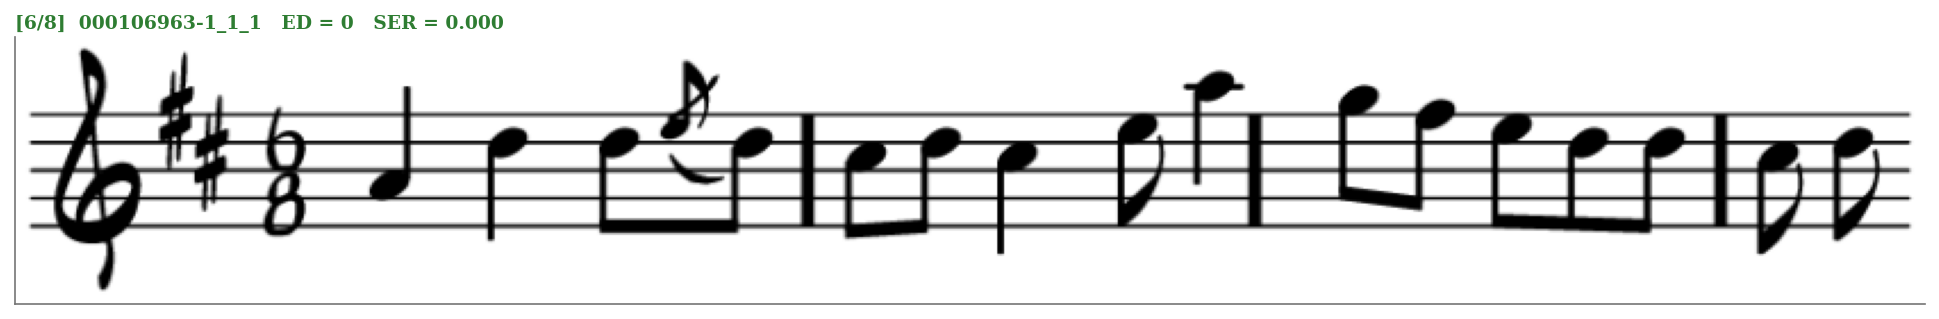

GT:    measure key:fifths:2 time beats:6 beat-type:8 clef:G2 A4 quarter rest half measure D5 quarter D5 eighth
         D5 eighth C5 eighth D5 eighth measure C5 quarter E5 eighth A5 quarter G5 eighth measure F5 eighth E5
         eighth D5 eighth D5 eighth C5 eighth D5 eighth
PRED:  measure key:fifths:2 time beats:6 beat-type:8 clef:G2 A4 quarter rest half measure D5 quarter D5 eighth
         D5 eighth C5 eighth D5 eighth measure C5 quarter E5 eighth A5 quarter G5 eighth measure F5 eighth E5
         eighth D5 eighth D5 eighth C5 eighth D5 eighth



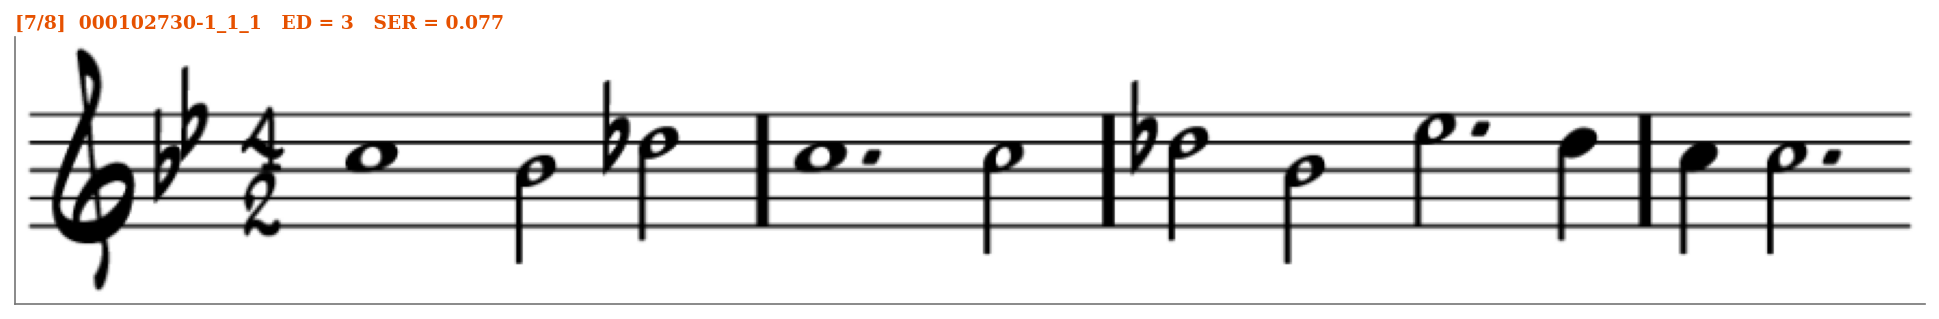

GT:    measure key:fifths:-2 time beats:4 beat-type:2 clef:G2 C5 whole B4 half D5 half flat measure C5 whole
         dot C5 half measure D5 half flat B4 half E5 half dot D5 quarter flat measure C5 quarter C5 half dot
         rest whole
PRED:  measure key:fifths:-2 time beats:4 beat-type:2 clef:G2 C5 whole B4 half D5 half flat measure C5 whole
         dot C5 half measure D5 half flat B4 half E5 half dot D5 quarter measure C5 quarter C5 half dot rest
         half dot



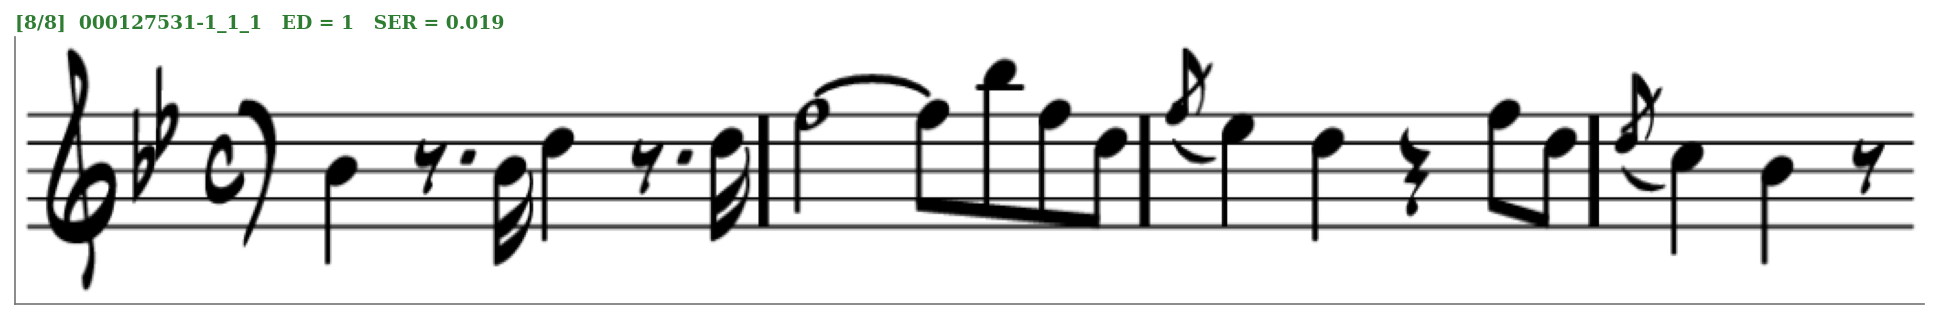

GT:    measure key:fifths:-2 time beats:4 beat-type:4 clef:G2 B4 quarter rest eighth dot B4 16th D5 quarter
         rest eighth dot D5 16th measure F5 half tied:start F5 eighth tied:stop B5 eighth F5 eighth D5 eighth
         measure E5 quarter D5 quarter rest quarter F5 eighth D5 eighth measure C5 quarter B4 quarter rest
         eighth rest quarter dot
PRED:  measure key:fifths:-2 time beats:4 beat-type:4 clef:C1 B4 quarter rest eighth dot B4 16th D5 quarter
         rest eighth dot D5 16th measure F5 half tied:start F5 eighth tied:stop B5 eighth F5 eighth D5 eighth
         measure E5 quarter D5 quarter rest quarter F5 eighth D5 eighth measure C5 quarter B4 quarter rest
         eighth rest quarter dot



In [24]:
show_predictions(results, test_ds, n=8, seed=42,
                 title_prefix="Random sample — qualitative check")

### 5.1 Near-median examples

To give a representative picture of *typical* model performance we also
show samples whose SER is close to the **median** of the distribution.

Median SER = 0.1600  |  tolerance = ±0.01  | 94 candidates
──────────────────────────────────────────────────────────────────────
  Near-median examples
──────────────────────────────────────────────────────────────────────



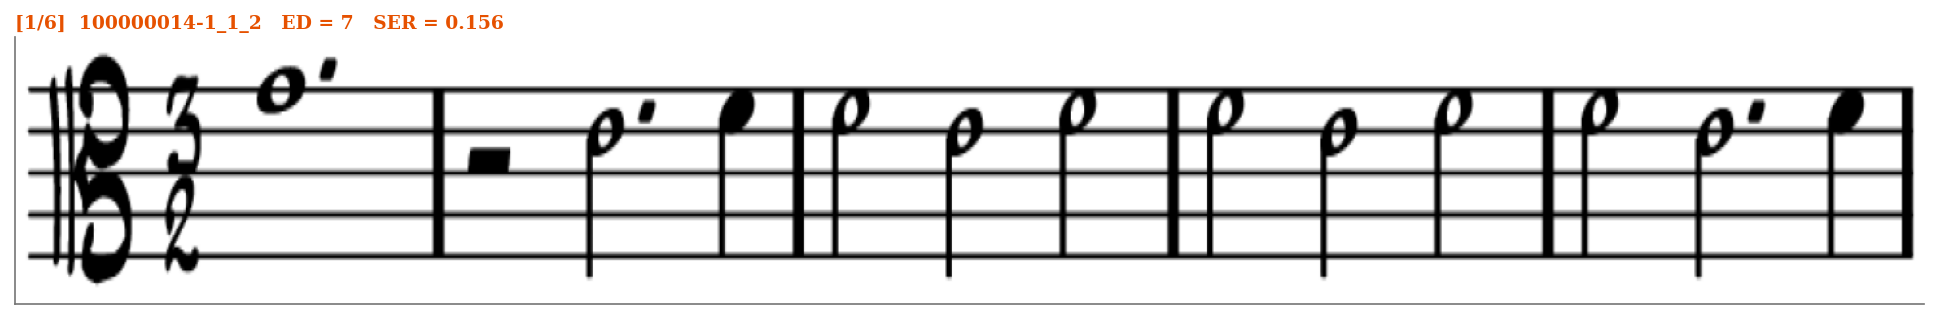

GT:    measure time beats:3 beat-type:2 clef:C3 G4 whole dot measure rest half E4 half dot F4 quarter measure
         F4 half tied:start E4 half tied:stop F4 half tied:start measure F4 half tied:start E4 half tied:stop
         F4 half tied:start measure F4 half tied:stop E4 half dot F4 quarter
PRED:  measure time beats:3 beat-type:2 clef:C3 G4 whole dot measure rest half E4 half dot F4 quarter measure
         F4 half E4 half F4 half measure F4 half E4 half F4 half measure F4 half E4 half dot F4 quarter



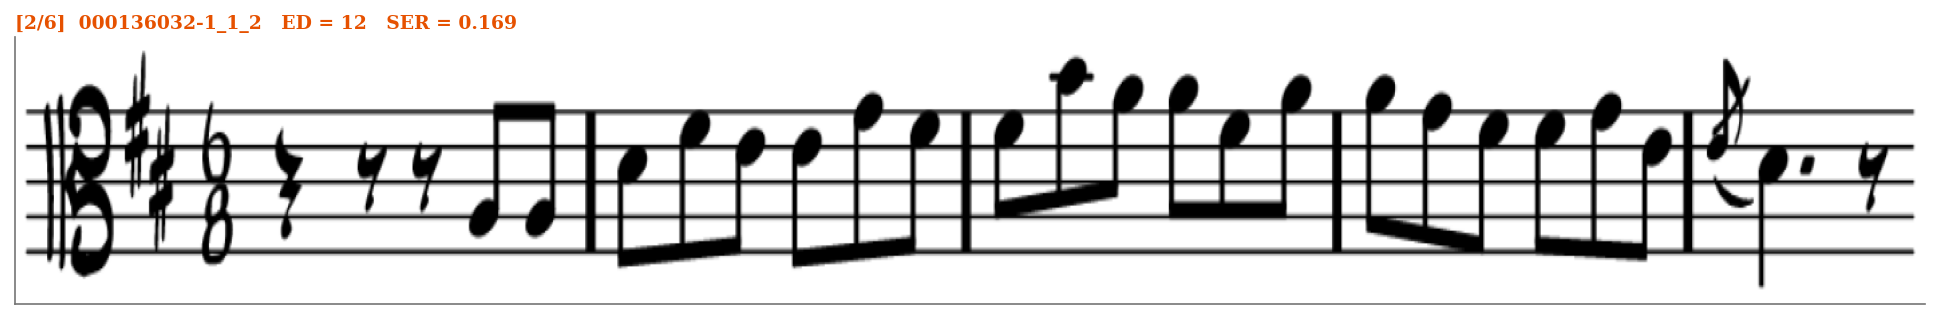

GT:    measure key:fifths:2 time beats:6 beat-type:8 clef:C3 rest rest:measure measure rest rest:measure rest
         quarter measure rest quarter rest eighth rest eighth A3 eighth A3 eighth measure D4 eighth F4 eighth
         E4 eighth E4 eighth G4 eighth F4 eighth measure F4 eighth B4 eighth A4 eighth A4 eighth F4 eighth A4
         eighth measure A4 eighth G4 eighth F4 eighth F4 eighth G4 eighth E4 eighth measure D4 quarter dot
         rest eighth rest quarter
PRED:  measure key:fifths:2 time beats:6 beat-type:8 clef:C3 rest eighth A3 eighth A3 eighth measure D4 eighth
         F4 eighth E4 eighth E4 eighth G4 eighth F4 eighth measure F4 eighth B4 eighth A4 eighth A4 eighth F4
         eighth A4 eighth measure A4 eighth G4 eighth F4 eighth F4 eighth G4 eighth E4 eighth measure D4
         quarter dot rest eighth rest quarter



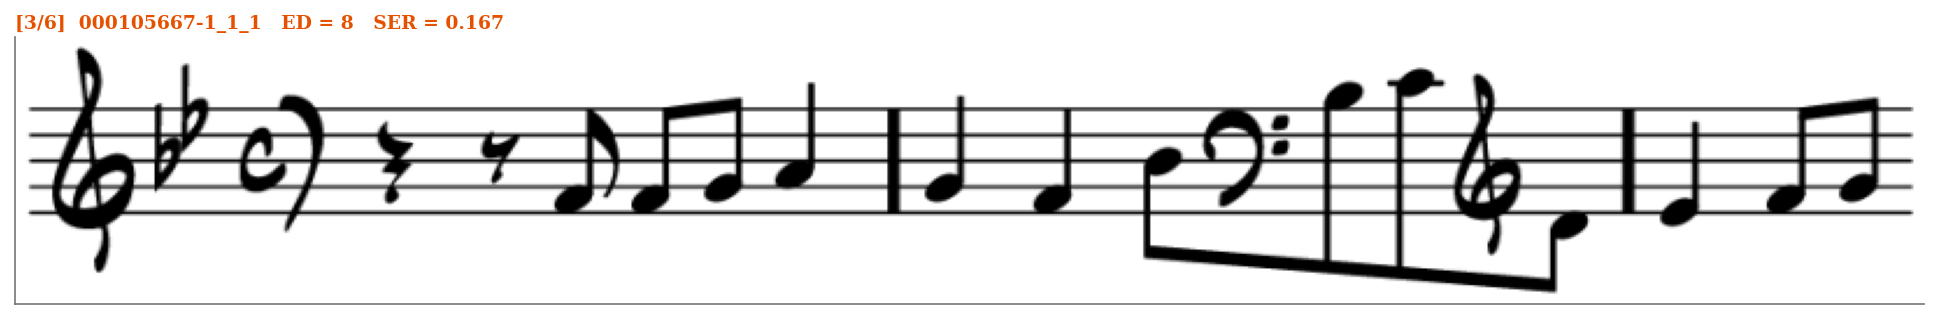

GT:    measure key:fifths:-2 time beats:4 beat-type:4 clef:G2 rest rest:measure measure rest rest:measure
         measure rest quarter rest eighth F4 eighth F4 eighth G4 eighth A4 quarter measure G4 quarter F4
         quarter B4 eighth clef:F4 B3 eighth C4 eighth clef:G2 D4 eighth measure E4 quarter F4 eighth G4
         eighth rest half
PRED:  measure key:fifths:-2 time beats:4 beat-type:4 clef:C1 rest quarter rest eighth F4 eighth F4 eighth G4
         eighth A4 quarter measure G4 quarter F4 quarter B4 eighth clef:F4 B3 eighth C4 eighth clef:C1 D4
         eighth measure E4 quarter F4 eighth G4 eighth rest half



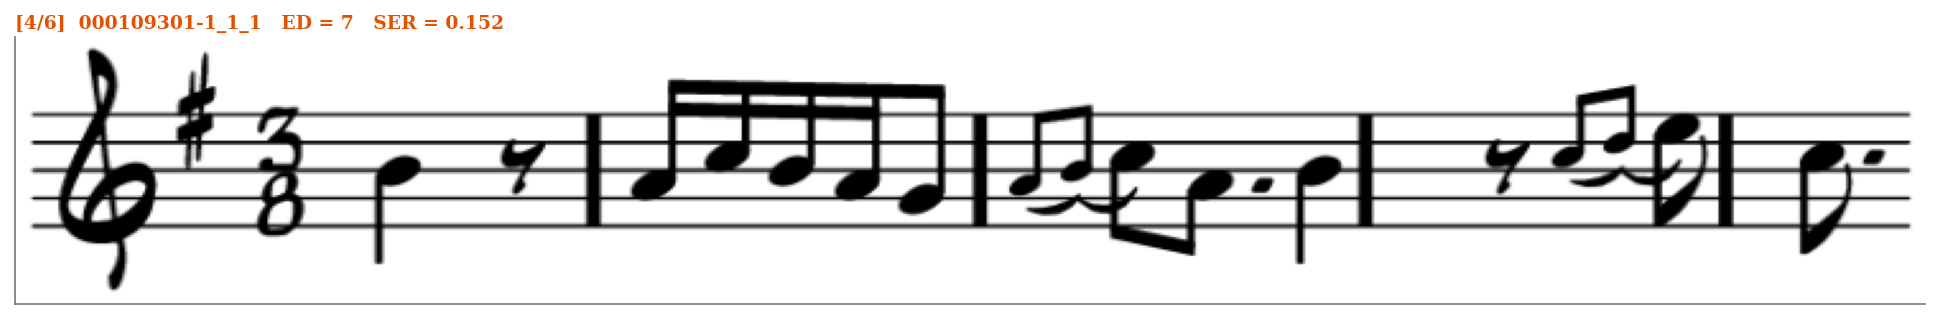

GT:    measure key:fifths:1 time beats:3 beat-type:8 clef:G2 B4 quarter rest eighth measure A4 16th C5 16th B4
         16th A4 16th G4 eighth measure C5 eighth A4 eighth dot G4 32nd A4 32nd measure B4 quarter rest eighth
         measure E5 eighth C5 eighth dot B4 32nd C5 32nd
PRED:  measure key:fifths:1 time beats:3 beat-type:8 clef:G2 B4 quarter rest eighth measure A4 16th C5 16th B4
         16th A4 16th G4 eighth measure C5 eighth A4 eighth dot B4 32nd measure B4 quarter rest eighth measure
         E5 eighth C5 eighth dot rest eighth 16th



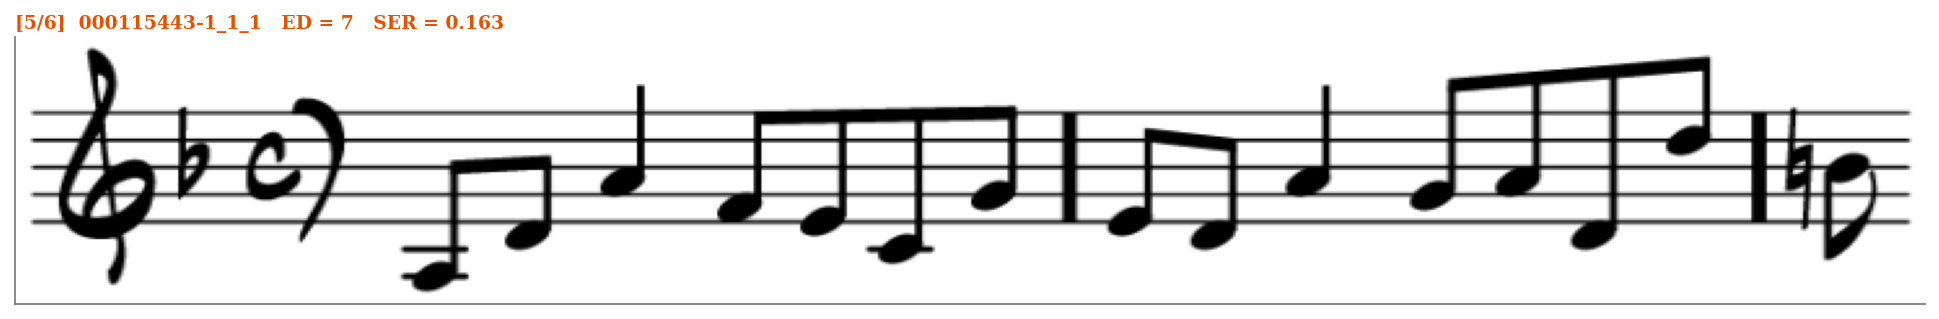

GT:    measure key:fifths:-1 time beats:4 beat-type:4 clef:G2 A3 eighth rest half dot dot measure D4 eighth A4
         quarter F4 eighth E4 eighth C4 eighth G4 eighth E4 eighth measure D4 eighth A4 quarter G4 eighth A4
         eighth D4 eighth D5 eighth B4 eighth natural
PRED:  measure key:fifths:-1 time beats:4 beat-type:4 clef:G2 A3 eighth D4 eighth rest half dot measure A4
         quarter F4 eighth E4 eighth C4 eighth G4 eighth E4 eighth D4 eighth measure A4 quarter G4 eighth A4
         eighth D4 eighth D5 eighth B4 eighth natural



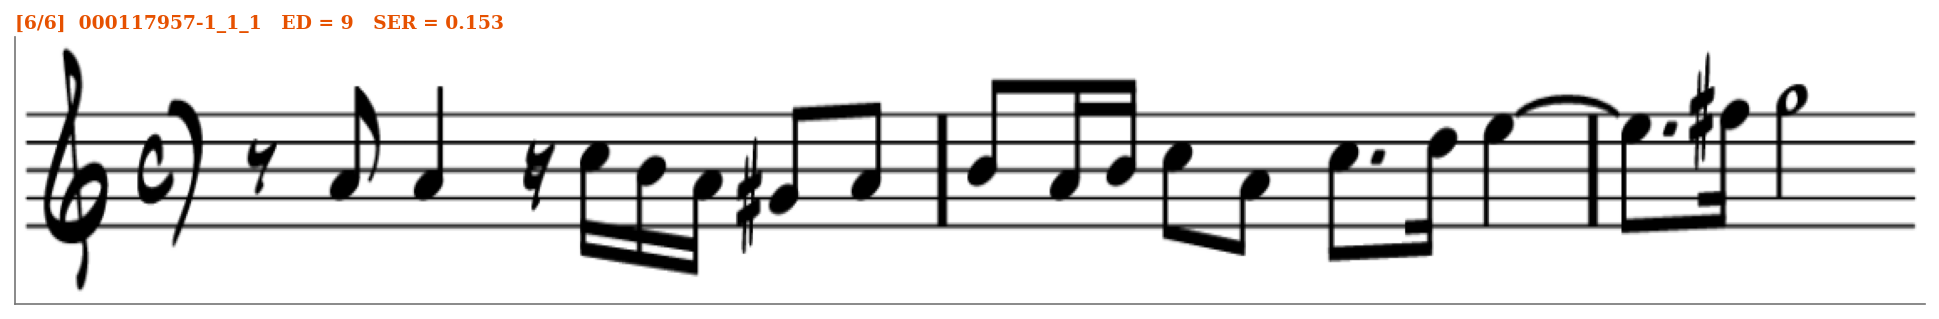

GT:    measure time beats:4 beat-type:4 clef:G2 rest eighth A4 eighth rest half dot measure A4 quarter rest
         16th C5 16th B4 16th A4 16th G4 eighth sharp A4 eighth B4 eighth A4 16th B4 16th measure C5 eighth A4
         eighth C5 eighth dot D5 16th E5 quarter tied:start E5 eighth dot tied:stop F5 16th sharp measure G5
         half rest half
PRED:  measure time beats:4 beat-type:4 clef:G2 rest eighth A4 eighth A4 quarter rest 16th C5 16th B4 16th A4
         16th G4 eighth sharp A4 eighth measure B4 eighth A4 16th B4 16th C5 eighth A4 eighth C5 eighth dot D5
         16th measure E5 quarter tied:start E5 eighth dot tied:stop F5 16th sharp G5 half rest quarter



In [25]:
median_ser = np.median(sers)
tolerance  = 0.01
near_median = np.where(np.abs(sers - median_ser) <= tolerance)[0]

# Widen tolerance if too few matches
while len(near_median) < 6 and tolerance < 0.5:
    tolerance += 0.01
    near_median = np.where(np.abs(sers - median_ser) <= tolerance)[0]

chosen = np.sort(np.random.default_rng(7).choice(
    near_median, size=min(6, len(near_median)), replace=False))

print(f"Median SER = {median_ser:.4f}  |  tolerance = ±{tolerance:.2f}  "
      f"| {len(near_median)} candidates")
show_predictions(results, test_ds, indices=chosen,
                 title_prefix="Near-median examples")

---
## 6. Error Analysis — Failure Modes

### 6.1 Worst predictions

Identify the test samples with the **highest** edit distance (not SER, so
short sequences with one error do not dominate). Inspecting these reveals
systematic failure modes — e.g. heavily distorted images, unusual symbol
patterns, or excessively long sequences.

──────────────────────────────────────────────────────────────────────
  Worst predictions (highest edit distance)
──────────────────────────────────────────────────────────────────────



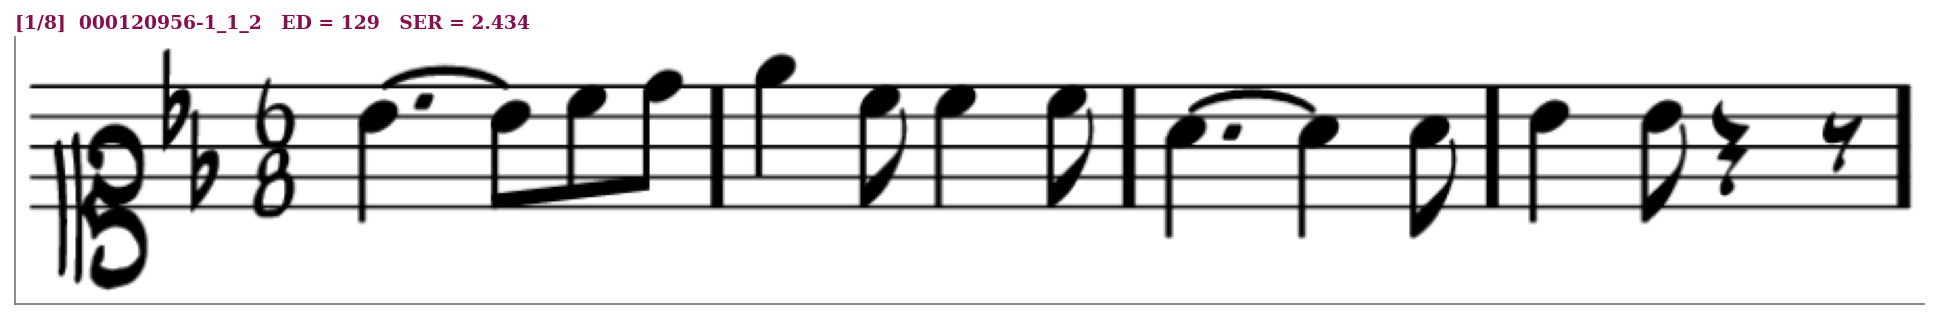

GT:    measure key:fifths:-2 time beats:6 beat-type:8 clef:C1 rest rest:measure measure rest rest:measure rest
         quarter measure B4 quarter dot tied:start B4 eighth tied:stop C5 eighth D5 eighth measure E5 quarter
         C5 eighth C5 quarter C5 eighth measure A4 quarter dot tied:start A4 quarter tied:stop A4 eighth
         measure B4 quarter B4 eighth rest quarter rest eighth
PRED:  measure key:fifths:-1 time beats:6 beat-type:8 clef:C4 rest rest:measure measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure
         rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest 

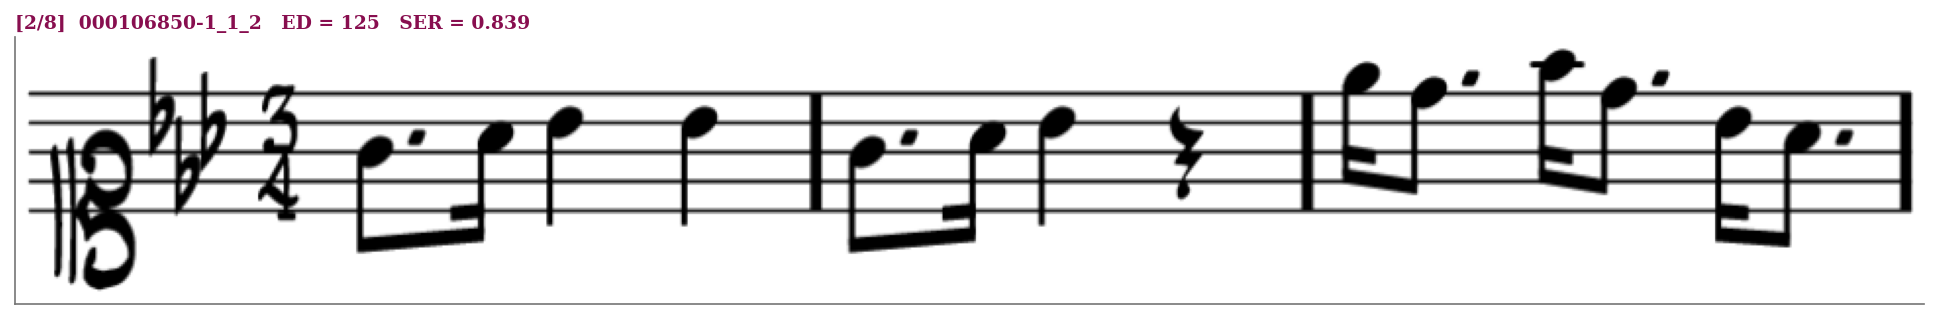

GT:    measure key:fifths:-3 time beats:3 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure G4 eighth do

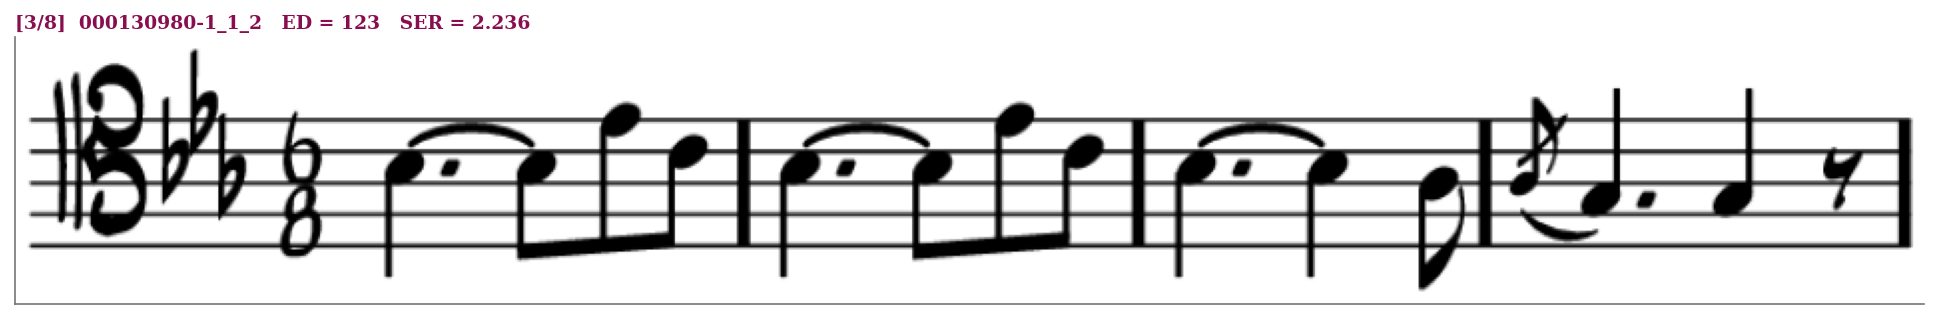

GT:    measure key:fifths:-3 time beats:6 beat-type:8 clef:C4 rest rest:measure measure rest rest:measure rest
         quarter measure B3 quarter dot tied:start B3 eighth tied:stop E4 eighth C4 eighth measure B3 quarter
         dot tied:start B3 eighth tied:stop E4 eighth C4 eighth measure B3 quarter dot tied:start B3 quarter
         tied:stop A3 eighth measure G3 quarter dot G3 quarter rest eighth
PRED:  measure key:fifths:-3 time beats:6 beat-type:8 clef:C4 rest rest:measure measure rest rest:measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest rest:measure measure rest rest:measure measure rest
         rest:measure measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure
         rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measu

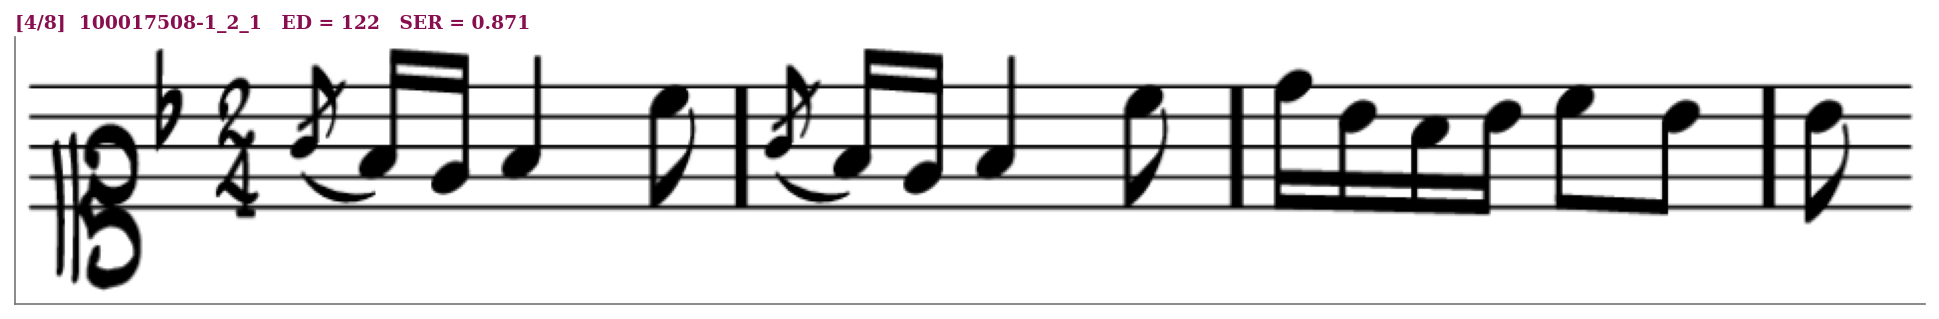

GT:    measure key:fifths:-1 time beats:2 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure rest
         rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure
         measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest
         rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure
         rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest
         rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure
         measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest
         rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure
         rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest
         rest:measure mea

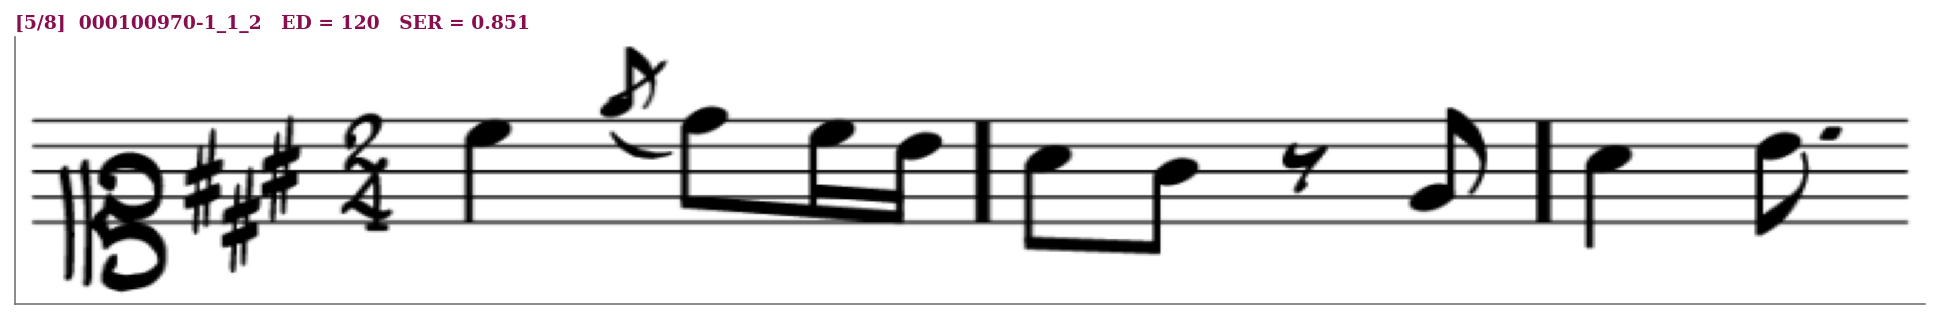

GT:    measure key:fifths:3 time beats:2 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure rest
         rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure
         measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest
         rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure
         rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest
         rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure
         measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest
         rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure
         rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest
         rest:measure meas

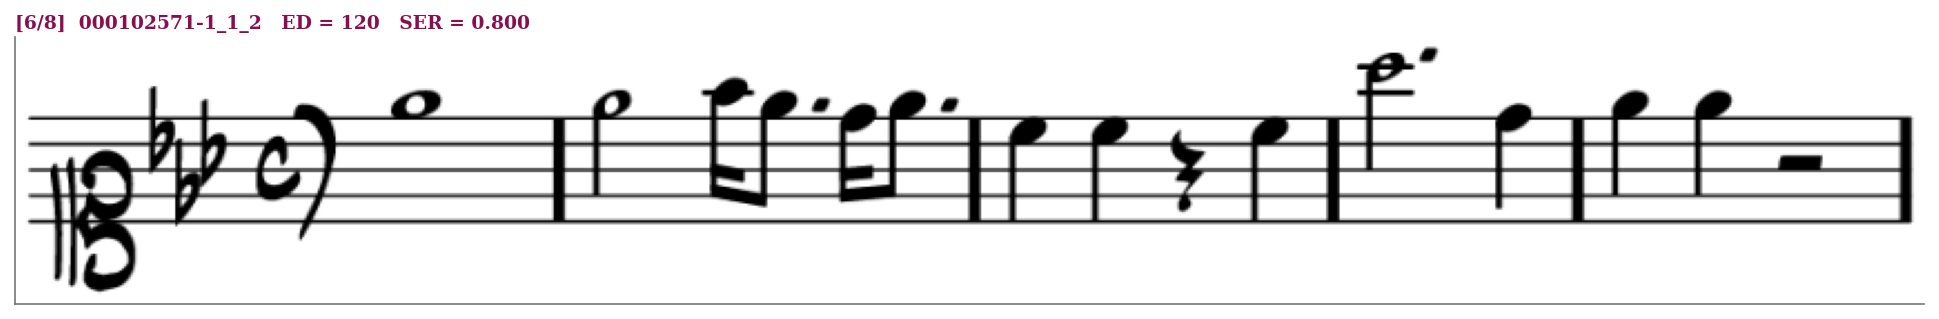

GT:    measure key:fifths:-3 time beats:4 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure
         measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest
         rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure
         rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure
         measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest
         rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure
         rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure
         measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest
         rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure
         rest rest:measure measure rest rest:measure measure

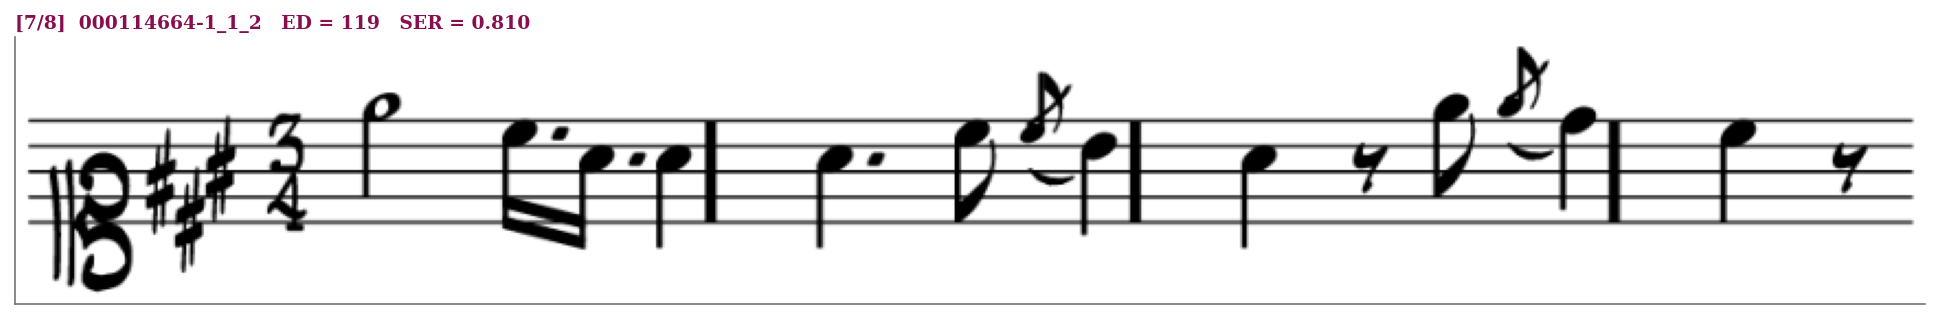

GT:    measure key:fifths:3 time beats:3 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest
         quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest
         rest:measure rest quarter measure rest rest:measure rest quarter measure E5 half D5 32nd C5 16th dot
         B4 32nd A4 16th dot meas

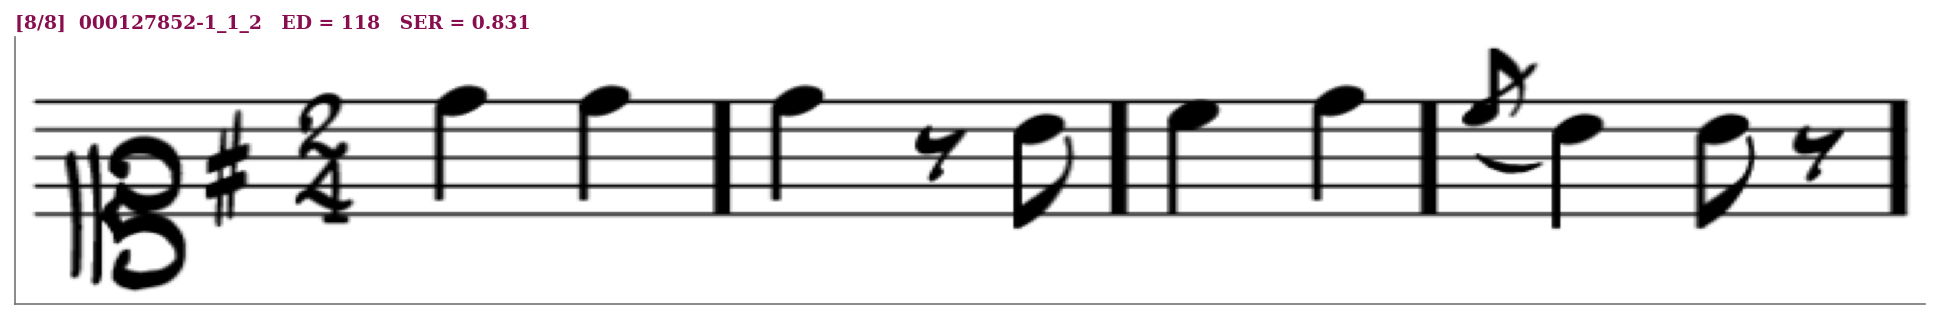

GT:    measure key:fifths:1 time beats:2 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure rest
         rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure
         measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest
         rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure
         rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest
         rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure
         measure rest rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest
         rest:measure rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure
         rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure rest
         rest:measure meas

In [26]:
# Sort by raw edit distance (descending)
ed_vals = np.array([r["ed"] for r in results])
worst   = np.argsort(ed_vals)[::-1][:8]

show_predictions(results, test_ds, indices=worst,
                 title_prefix="Worst predictions (highest edit distance)")


### 6.2 Error-type breakdown (substitutions / insertions / deletions)

We trace back through the dynamic-programming matrix of the Levenshtein
algorithm to classify each edit operation. This tells us whether the model
mainly *confuses* symbols (substitution), *hallucinates* extra tokens
(insertion), or *drops* tokens (deletion).

In [27]:
def _edit_ops(hyp: list[str], ref: list[str]) -> list[str]:
    """Return the sequence of edit operations (match / sub / ins / del)
    by backtracking through the full Levenshtein matrix."""
    n, m = len(hyp), len(ref)
    # Build full DP matrix
    mat = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(n + 1):
        mat[i, 0] = i
    for j in range(m + 1):
        mat[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if hyp[i - 1] == ref[j - 1] else 1
            mat[i, j] = min(
                mat[i - 1, j] + 1,       # deletion from hyp (insertion in ref)
                mat[i, j - 1] + 1,       # insertion in hyp (deletion from ref)
                mat[i - 1, j - 1] + cost, # match / substitution
            )
    # Backtrace
    ops: list[str] = []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0 and mat[i, j] == mat[i-1, j-1] + (0 if hyp[i-1] == ref[j-1] else 1):
            ops.append("match" if hyp[i-1] == ref[j-1] else "sub")
            i -= 1; j -= 1
        elif i > 0 and mat[i, j] == mat[i-1, j] + 1:
            ops.append("ins")   # model inserted an extra token
            i -= 1
        else:
            ops.append("del")   # model deleted / missed a token
            j -= 1
    ops.reverse()
    return ops


# Aggregate edit operations across the full test set
total_r = {"sub": 0, "ins": 0, "del": 0, "match": 0}
sub_counts = collections.Counter()  # which token pairs are confused
del_counts = collections.Counter()  # which tokens are most often deleted
ins_counts = collections.Counter()  # which tokens are most often inserted

for r in results:
    ops = _edit_ops(r["pred"], r["ref"])
    hi, hj = 0, 0  # pointers into hyp / ref
    for op in ops:
        total_r[op] += 1
        if op == "sub":
            sub_counts[(r["ref"][hj], r["pred"][hi])] += 1
            hi += 1; hj += 1
        elif op == "ins":
            ins_counts[r["pred"][hi]] += 1
            hi += 1
        elif op == "del":
            del_counts[r["ref"][hj]] += 1
            hj += 1
        else:  # match
            hi += 1; hj += 1

total_errors = total_r["sub"] + total_r["ins"] + total_r["del"]
total_matched = total_r["match"]

print("Error-type breakdown (all test samples)")
print(f"  Substitutions : {total_r['sub']:>6d}  ({total_r['sub']/max(total_errors,1)*100:5.1f}%)")
print(f"  Insertions    : {total_r['ins']:>6d}  ({total_r['ins']/max(total_errors,1)*100:5.1f}%)")
print(f"  Deletions     : {total_r['del']:>6d}  ({total_r['del']/max(total_errors,1)*100:5.1f}%)")
print(f"  ──────────────────────────")
print(f"  Total errors  : {total_errors:>6d}")
print(f"  Matches       : {total_matched:>6d}")

Error-type breakdown (all test samples)
  Substitutions :  23744  ( 36.6%)
  Insertions    :   8968  ( 13.8%)
  Deletions     :  32174  ( 49.6%)
  ──────────────────────────
  Total errors  :  64886
  Matches       : 184601


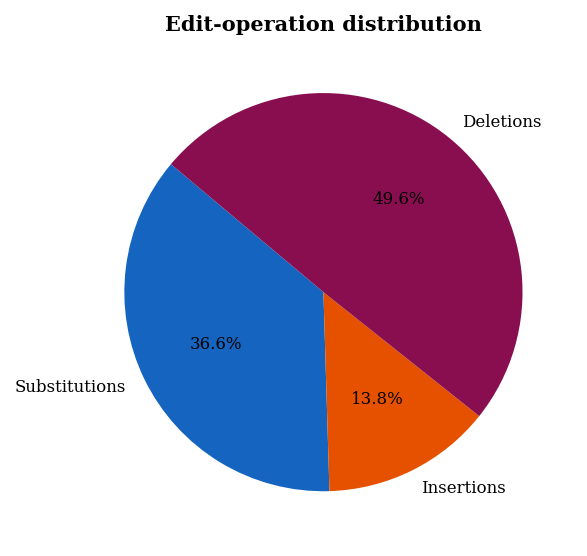

In [28]:
# ── Pie chart of error types ───────────────────────────────────────────
err_labels = ["Substitutions", "Insertions", "Deletions"]
sizes  = [total_r["sub"], total_r["ins"], total_r["del"]]
colors = [style.C["primary"], style.C["secondary"], style.C["highlight"]]

fig, ax = plt.subplots(figsize=(4, 4))
wedges, texts, autotexts = ax.pie(
    sizes, labels=err_labels, colors=colors, autopct="%1.1f%%",
    startangle=140, textprops={"fontsize": 8},
)
ax.set_title("Edit-operation distribution", fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()

### 6.3 Most common confused / deleted / inserted tokens

Rank the specific tokens (or token pairs) that contribute the most errors.
This guides targeted improvements — e.g. if durations are consistently
confused, we might augment training data with more rhythmic variety.

In [29]:
TOP_N = 15

print(f"Top-{TOP_N} substitution pairs (ref → pred):")
for (ref_tok, r_tok), cnt in sub_counts.most_common(TOP_N):
    print(f"  {ref_tok:>25s}  →  {r_tok:<25s}  ×{cnt}")

print(f"\nTop-{TOP_N} deleted tokens (model missed):")
for tok, cnt in del_counts.most_common(TOP_N):
    print(f"  {tok:>25s}  ×{cnt}")

print(f"\nTop-{TOP_N} inserted tokens (model hallucinated):")
for tok, cnt in ins_counts.most_common(TOP_N):
    print(f"  {tok:>25s}  ×{cnt}")

Top-15 substitution pairs (ref → pred):
                         C5  →  D4                         ×1864
                         B4  →  C4                         ×1792
                         A4  →  B3                         ×1649
                         D5  →  E4                         ×1378
                         G4  →  A3                         ×1047
                         E5  →  F4                         ×939
                         F4  →  G3                         ×688
                    clef:C1  →  clef:C4                    ×580
                         A4  →  D4                         ×546
                         B4  →  E4                         ×501
                         C5  →  E5                         ×422
                         E4  →  F3                         ×418
                         C5  →  F4                         ×397
                         D5  →  F5                         ×384
                         G4  →  C4                         

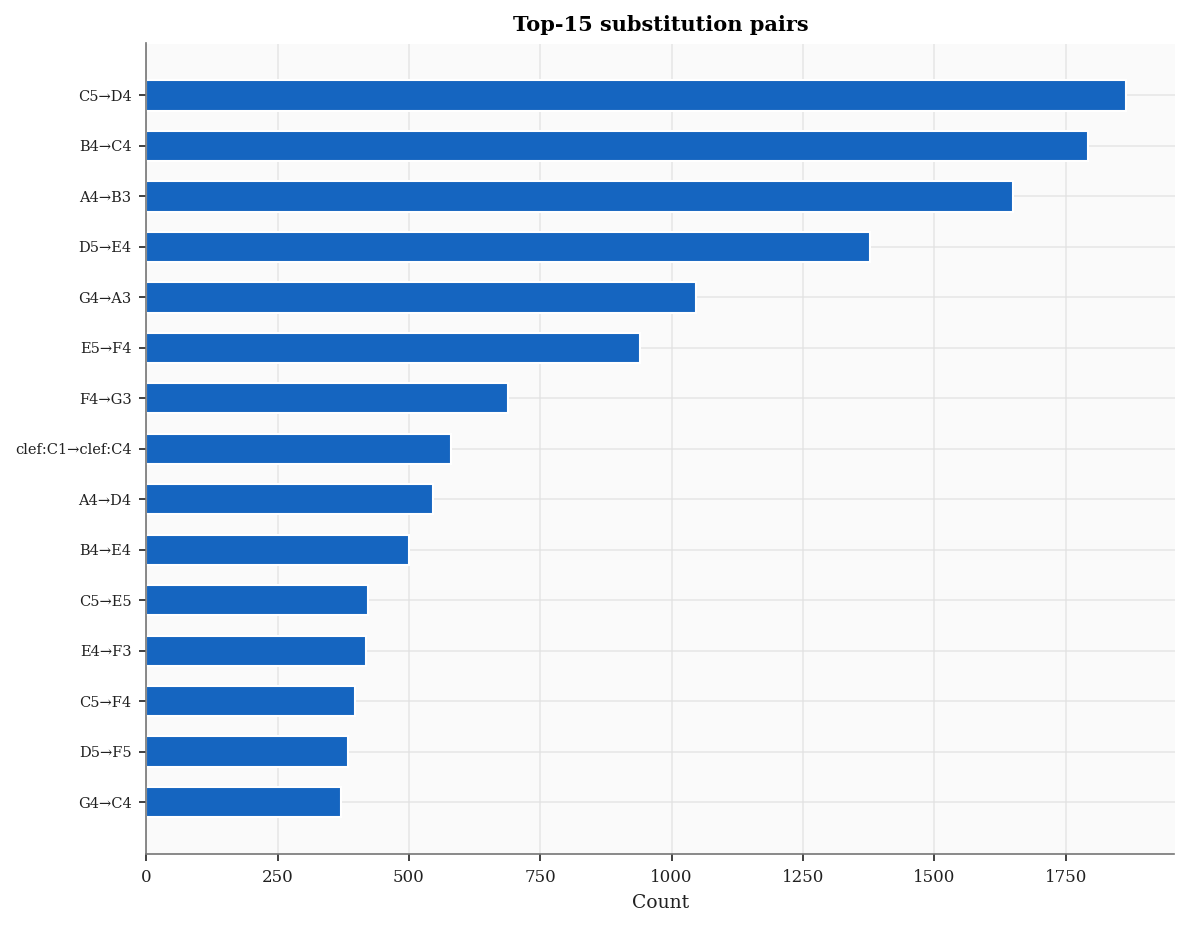

In [30]:
# ── Bar chart of top confused pairs ────────────────────────────────────
top_pairs = sub_counts.most_common(TOP_N)
if top_pairs:
    labels = [f"{a}→{b}" for (a, b), _ in top_pairs]
    vals   = [c for _, c in top_pairs]

    fig, ax = plt.subplots(figsize=(8, 0.35 * len(labels) + 1))
    y = np.arange(len(labels))
    ax.barh(y, vals, color=style.C["primary"], edgecolor="white", height=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Top-{TOP_N} substitution pairs", fontsize=10, fontweight="bold")
    fig.tight_layout()
    plt.show()

### 6.4 SER vs. sequence length

Scatter SER against ground-truth sequence length to check whether the
model degrades on longer (or shorter) inputs — a common failure mode
for CTC-based systems.

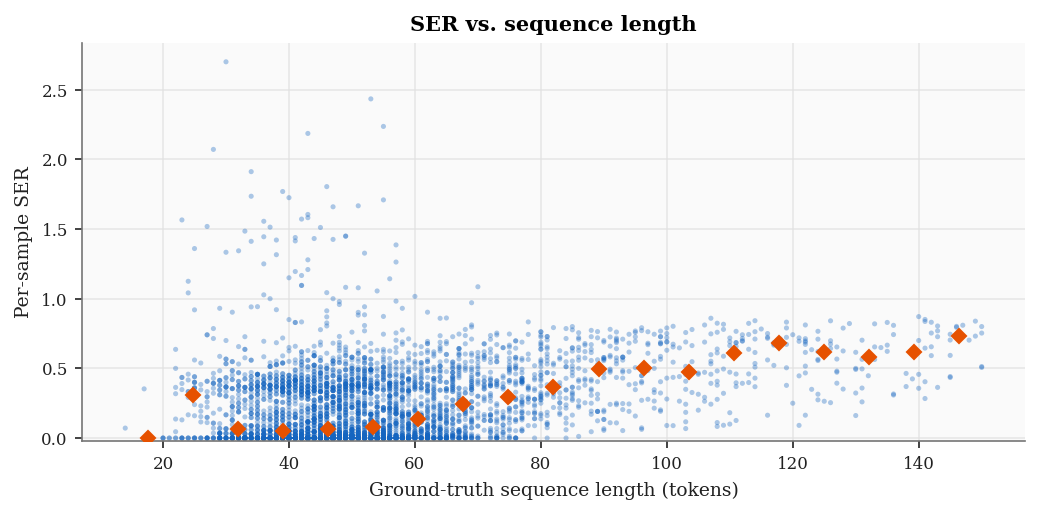

In [31]:
ref_lens = np.array([len(r["ref"]) for r in results])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(ref_lens, sers, s=6, alpha=0.35, color=style.C["primary"],
           edgecolors="none")

# Running median for trend
bins = np.linspace(ref_lens.min(), ref_lens.max(), 20)
dig  = np.digitize(ref_lens, bins)
for b in range(1, len(bins)):
    mask = dig == b
    if mask.sum() > 2:
        ax.plot(bins[b-1:b+1].mean(), np.median(sers[mask]),
                "D", ms=5, color=style.C["secondary"], zorder=5)

ax.set_xlabel("Ground-truth sequence length (tokens)")
ax.set_ylabel("Per-sample SER")
ax.set_title("SER vs. sequence length", fontsize=10, fontweight="bold")
ax.set_ylim(-0.02, min(sers.max() * 1.05, 3.0))
fig.tight_layout()
plt.show()

### 6.5 Summary

Collect the main metrics in one cell for quick reference.

In [32]:
pct_perfect = (sers == 0).mean() * 100
pct_le05    = (sers <= 0.05).mean() * 100
pct_le10    = (sers <= 0.10).mean() * 100
pct_over1   = (sers > 1.0).mean() * 100
med_ser     = float(np.median(sers))

summary = f"""
╔══════════════════════════════════════════════════╗
║        Phase 4 — Test-Set Evaluation Summary     ║
╠══════════════════════════════════════════════════╣
║  Aggregate SER          : {agg_ser:>8.4f}               ║
║  Median per-sample SER  : {med_ser:>8.4f}               ║
║  Perfect (SER = 0)      : {pct_perfect:>6.1f}%                ║
║  SER ≤ 5%               : {pct_le05:>6.1f}%                ║
║  SER ≤ 10%              : {pct_le10:>6.1f}%                ║
║  SER > 100%             : {pct_over1:>6.1f}%                ║
║  Total test samples     : {len(results):>6d}                 ║
║  Model parameters       : {n_params:>10,}             ║
║  Best checkpoint epoch  : {best_epoch:>6d}                 ║
╚══════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════╗
║        Phase 4 — Test-Set Evaluation Summary     ║
╠══════════════════════════════════════════════════╣
║  Aggregate SER          :   0.2698               ║
║  Median per-sample SER  :   0.1600               ║
║  Perfect (SER = 0)      :   26.2%                ║
║  SER ≤ 5%               :   36.9%                ║
║  SER ≤ 10%              :   43.8%                ║
║  SER > 100%             :    1.3%                ║
║  Total test samples     :   4355                 ║
║  Model parameters       :  4,229,598             ║
║  Best checkpoint epoch  :     18                 ║
╚══════════════════════════════════════════════════╝

